🎯 현재 연산 디바이스: cuda
📊 CSV 데이터셋 로드 완료! (총 샘플 수: 303개)


Map:   0%|          | 0/242 [00:00<?, ? examples/s]

Map:   0%|          | 0/61 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: skt/kobert-base-v1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 3, 'bos_token_id': 2}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔎 테스트 데이터셋 검증 중...



=== 📝 KoBERT 상세 평가지표 ===
              precision    recall  f1-score   support

   Normal(0)       0.87      1.00      0.93        34
 Phishing(1)       1.00      0.81      0.90        27

    accuracy                           0.92        61
   macro avg       0.94      0.91      0.91        61
weighted avg       0.93      0.92      0.92        61



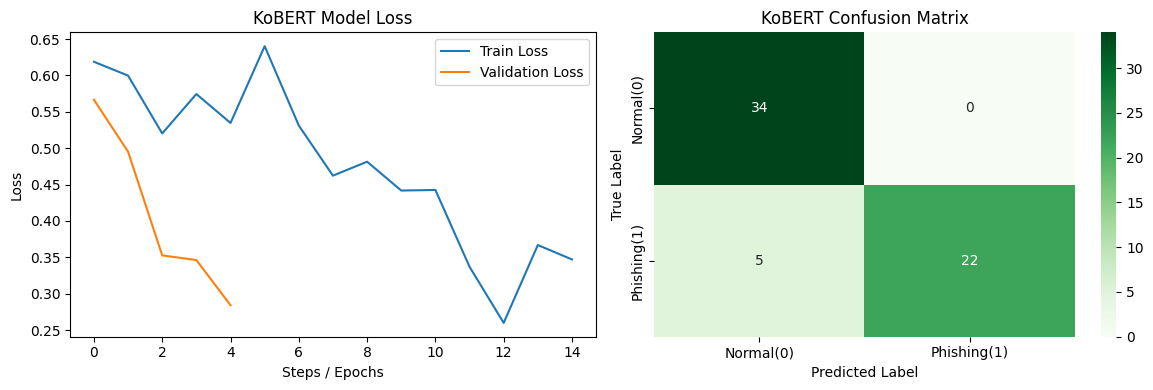

In [11]:
# 1. 필수 패키지 설치
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# 시드 고정 및 디바이스 설정
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🎯 현재 연산 디바이스: {device}")

# 2. 백업된 CSV 파일 다이렉트 로드
csv_path = '/content/phishing_dataset.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError("❌ 왼쪽 파일 창에 'phishing_dataset.csv' 파일이 없습니다! 마우스로 드래그해서 넣어주세요.")

df = pd.read_csv(csv_path)
df['text'] = df['text'].fillna('')

print(f"📊 CSV 데이터셋 로드 완료! (총 샘플 수: {len(df)}개)")

# 3. 데이터 분리 및 토큰화 (강의 노트 NLP 파이프라인 반영)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=seed, stratify=df['label']
)

model_name = "skt/kobert-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. KoBERT 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# 하이퍼파라미터 세팅
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none"
)

# ⭐ 최신 버전 스펙에 맞춰 tokenizer를 processing_class로 변경 완료!
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n🚀 KoBERT 기반 피싱 분류 Fine-tuning 시작...")
trainer.train()

print("\n🔎 테스트 데이터셋 검증 중...")
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = test_df['label'].values

print("\n=== 📝 KoBERT 상세 평가지표 ===")
print(classification_report(y_test, y_pred, target_names=['Normal(0)', 'Phishing(1)']))

# 5. 시각화 그래프 출력
history = trainer.state.log_history
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
if eval_loss:
    plt.plot(eval_loss, label='Validation Loss')
plt.title('KoBERT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Steps / Epochs')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal(0)', 'Phishing(1)'],
            yticklabels=['Normal(0)', 'Phishing(1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('KoBERT Confusion Matrix')

plt.tight_layout()
plt.show()

# 6. 최종 실시간 사진 판별 추론 함수
import easyocr
reader = easyocr.Reader(['ko', 'en'], gpu=True)

def predict_phishing_danger(image_path):
    result = reader.readtext(image_path, detail=0)
    extracted_text = " ".join(result)

    if not extracted_text.strip():
        print("\n🍏 [안전] 이미지에서 추출된 텍스트가 없어 안전한 페이지로 판단됩니다.")
        return

    inputs = tokenizer(extracted_text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    phishing_prob = probabilities[1]
    pred_class = int(phishing_prob > 0.5)

    print("\n" + "="*20 + " 🚨 실시간 웹사이트 위험도 스캔 🚨 " + "="*20)
    print(f"🔎 [이미지 스캔 문장]: {extracted_text}")
    print(f"📊 #-- Y_predicted_probability --# : {phishing_prob:.6f}")
    print(f"📊 #-- Y_predicted_classes --#     : {pred_class}")
    print("-"*65)

    if pred_class == 1:
        print(f"🚨 [경고] 피싱 위험도가 {phishing_prob*100:.2f}%로 매우 높습니다! 접속을 차단합니다.")
    else:
        print(f"🍏 [안전] 피싱 위험도가 {phishing_prob*100:.2f}%로 안전한 정상 사이트입니다.")
    print("="*66)